In [3]:
import pandas as pd

df=pd.read_csv('loan_approved.csv')

In [3]:
df.head()


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status (Approved)
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


loan_id->nominal
explanation:it is an identifier;no order


gender->nominal
explanation:categories(male/female);no order


married->nominal
explanation:categories(yes/no);no order


dependents->ordinal(discrete)
explanation:like 0,1,2,+3 ;order

Education	Nominal	
Categories (Graduate/Not Graduate); not ordered.


Self_Employed	Nominal	
Categories (Yes/No); no order.


ApplicantIncome	Discrete	
Countable integer income values; cannot take fractional values (₹ countable units).


CoapplicantIncome	Discrete	
Represented as numbers but logically countable income values; not measured continuously.


LoanAmount	Discrete	
Represented in fixed units; loan amounts are countable (no true continuous measurement).


Loan_Amount_Term	Ordinal	
Longer term > shorter term; values like 180, 240, 360 have a meaningful order.


Credit_History	Ordinal
0 = bad, 1 = good. Represents a ranking (good > bad).


Property_Area	Nominal	
Categories (Urban/Rural/Semiurban); cannot be ordered.


Loan_Status (Approved)	
Nominal	Categories (Y/N); no order.

In [4]:
df.shape

(614, 13)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Loan_ID                 614 non-null    object 
 1   Gender                  601 non-null    object 
 2   Married                 611 non-null    object 
 3   Dependents              599 non-null    object 
 4   Education               614 non-null    object 
 5   Self_Employed           582 non-null    object 
 6   ApplicantIncome         614 non-null    int64  
 7   CoapplicantIncome       614 non-null    float64
 8   LoanAmount              592 non-null    float64
 9   Loan_Amount_Term        600 non-null    float64
 10  Credit_History          564 non-null    float64
 11  Property_Area           614 non-null    object 
 12  Loan_Status (Approved)  614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [ ]:
len(df['Loan_ID'].unique()) #-categorical nominal

614

In [8]:
len(df['Gender'].unique()) #-categorical nominal

3

In [ ]:
len(df['Married'].unique()) #-categorical nominal

3

In [10]:
df['Married'].unique()

array(['No', 'Yes', nan], dtype=object)

In [ ]:
len(df['Dependents'].unique()) #=categorical ordinal
df['Dependents'].unique()

array(['0', '1', '2', '3+', nan], dtype=object)

In [ ]:
len(df['Education'].unique())
df['Education'].unique()#-categorical nominal

array(['Graduate', 'Not Graduate'], dtype=object)

In [18]:
df['CoapplicantIncome'].isna().sum()#-continuous col

np.int64(0)

<Axes: xlabel='CoapplicantIncome', ylabel='Count'>

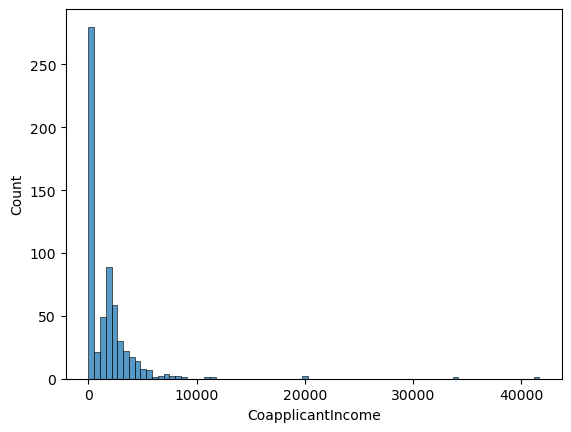

In [15]:
import seaborn as sns
sns.histplot(df['CoapplicantIncome'])

In [20]:
df['Loan_Amount_Term'].unique()   #-discrete col


array([360., 120., 240.,  nan, 180.,  60., 300., 480.,  36.,  84.,  12.])

In [ ]:
df['Credit_History'].unique()   #-ordinal

array([ 1.,  0., nan])

Gender --- Mode reason:categorical
Married --- Mode reason:Categorical
Dependents --- Mode reason:ordered categorical
Education --- Mode reason:category
Self_Employed --- Mode reason:Categories
ApplicantIncome --- Median reason:numeric (skewed or outliers)
CoapplicantIncome --- 


In [22]:
mode_cols = ['Gender', 'Married', 'Dependents', 'Education',
             'Self_Employed', 'Credit_History', 'Property_Area']

df[mode_cols] = df[mode_cols].fillna(df[mode_cols].mode().iloc[0])

<Axes: xlabel='Dependents', ylabel='count'>

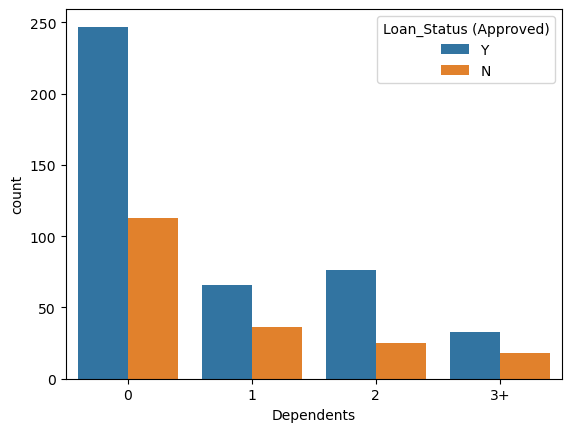

In [26]:
sns.countplot(x='Dependents',data=df,hue='Loan_Status (Approved)')

In [18]:
mean=df['ApplicantIncome'].mean()
m=df['ApplicantIncome'].max()
print(m)
print(df['ApplicantIncome'].min())
print(mean)
st=df['ApplicantIncome'].std()
print(st)

81000
150
5403.459283387622
6109.041673387174


In [11]:
z1=(5849-mean)/st
print(z1)

0.07293135984867927


In [13]:
z2=(4583-mean)/st
print(z2)

-0.13430245319192863


In [15]:
z3=(3000-mean)/st
print(z3)

-0.3934265653904138


In [19]:
df['Credit_History'].value_counts()

Credit_History
1.0    475
0.0     89
Name: count, dtype: int64

In [20]:
df['Gender'].value_counts()

Gender
Male      489
Female    112
Name: count, dtype: int64

In [ ]:
print(df['ApplicantIncome'].skew())  #highly skewed
print(df['ApplicantIncome'].kurtosis())

6.539513113994625
60.54067593369113


In [ ]:
print(df['CoapplicantIncome'].skew()) #highly skewed
print(df['CoapplicantIncome'].kurtosis())

7.491531216657306
84.95638421103374


In [ ]:
print(df['LoanAmount'].skew())  #highly skewed
print(df['LoanAmount'].kurtosis())

2.677551679256059
10.40153349029416


In [ ]:
print(df['Loan_Amount_Term'].skew())  #highly skewed
print(df['Loan_Amount_Term'].kurtosis())

-2.362414124216269
6.673473692814259


In [32]:
df["Property_Area"].unique()

array(['Urban', 'Rural', 'Semiurban'], dtype=object)

In [33]:
df["Property_Area"].isna().sum()

np.int64(0)

In [34]:
df["Property_Area"].shape

(614,)

### one hot encoding

In [39]:
df1=pd.get_dummies(df['Property_Area'],dtype=int,prefix='PA',drop_first=True)
df=pd.concat([df,df1],axis=1).drop(['Property_Area'],axis=1)


KeyError: 'Property_Area'

preprocessing of categorical data

In [40]:
df1=pd.get_dummies(df['Gender'],dtype=int,prefix='',drop_first=True)
df=pd.concat([df,df1],axis=1).drop(['Gender'],axis=1)


In [41]:
df.head()

,Loan_ID,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status (Approved),PA_Semiurban,PA_Urban,_Male
0,LP001002,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Y,0,1,1
1,LP001003,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,N,0,0,1
2,LP001005,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Y,0,1,1
3,LP001006,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Y,0,1,1
4,LP001008,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Y,0,1,1


In [42]:
df1=pd.get_dummies(df['Married'],dtype=int,prefix='',drop_first=True)
df=pd.concat([df,df1],axis=1).drop(['Married'],axis=1)


In [43]:
df.head()

,Loan_ID,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status (Approved),PA_Semiurban,PA_Urban,_Male,_Yes
0,LP001002,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Y,0,1,1,0
1,LP001003,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,N,0,0,1,1
2,LP001005,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Y,0,1,1,1
3,LP001006,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Y,0,1,1,1
4,LP001008,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Y,0,1,1,0


In [44]:
df1=pd.get_dummies(df['Education'],dtype=int,prefix='',drop_first=True)
df=pd.concat([df,df1],axis=1).drop(['Education'],axis=1)


In [45]:
df.head()

,Loan_ID,Dependents,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status (Approved),PA_Semiurban,PA_Urban,_Male,_Yes,_Not Graduate
0,LP001002,0,No,5849,0.0,NaN,360.0,1.0,Y,0,1,1,0,0
1,LP001003,1,No,4583,1508.0,128.0,360.0,1.0,N,0,0,1,1,0
2,LP001005,0,Yes,3000,0.0,66.0,360.0,1.0,Y,0,1,1,1,0
3,LP001006,0,No,2583,2358.0,120.0,360.0,1.0,Y,0,1,1,1,1
4,LP001008,0,No,6000,0.0,141.0,360.0,1.0,Y,0,1,1,0,0


In [46]:
df1=pd.get_dummies(df['Dependents'],dtype=int,prefix='',drop_first=True)
df=pd.concat([df,df1],axis=1).drop(['Dependents'],axis=1)


In [47]:
df.head()

,Loan_ID,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status (Approved),PA_Semiurban,PA_Urban,_Male,_Yes,_Not Graduate,_1,_2,_3+
0,LP001002,No,5849,0.0,NaN,360.0,1.0,Y,0,1,1,0,0,0,0,0
1,LP001003,No,4583,1508.0,128.0,360.0,1.0,N,0,0,1,1,0,1,0,0
2,LP001005,Yes,3000,0.0,66.0,360.0,1.0,Y,0,1,1,1,0,0,0,0
3,LP001006,No,2583,2358.0,120.0,360.0,1.0,Y,0,1,1,1,1,0,0,0
4,LP001008,No,6000,0.0,141.0,360.0,1.0,Y,0,1,1,0,0,0,0,0


In [48]:
df1=pd.get_dummies(df['Self_Employed'],dtype=int,prefix='',drop_first=True)
df=pd.concat([df,df1],axis=1).drop(['Self_Employed'],axis=1)


In [49]:
df.head()

,Loan_ID,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status (Approved),PA_Semiurban,PA_Urban,_Male,_Yes,_Not Graduate,_1,_2,_3+,_Yes
0,LP001002,5849,0.0,NaN,360.0,1.0,Y,0,1,1,0,0,0,0,0,0
1,LP001003,4583,1508.0,128.0,360.0,1.0,N,0,0,1,1,0,1,0,0,0
2,LP001005,3000,0.0,66.0,360.0,1.0,Y,0,1,1,1,0,0,0,0,1
3,LP001006,2583,2358.0,120.0,360.0,1.0,Y,0,1,1,1,1,0,0,0,0
4,LP001008,6000,0.0,141.0,360.0,1.0,Y,0,1,1,0,0,0,0,0,0


In [50]:
df1=pd.get_dummies(df['Credit_History'],dtype=int,prefix='',drop_first=True)
df=pd.concat([df,df1],axis=1).drop(['Credit_History'],axis=1)


In [51]:
df.head()

,Loan_ID,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Loan_Status (Approved),PA_Semiurban,PA_Urban,_Male,_Yes,_Not Graduate,_1,_2,_3+,_Yes,_1.0
0,LP001002,5849,0.0,NaN,360.0,Y,0,1,1,0,0,0,0,0,0,1
1,LP001003,4583,1508.0,128.0,360.0,N,0,0,1,1,0,1,0,0,0,1
2,LP001005,3000,0.0,66.0,360.0,Y,0,1,1,1,0,0,0,0,1,1
3,LP001006,2583,2358.0,120.0,360.0,Y,0,1,1,1,1,0,0,0,0,1
4,LP001008,6000,0.0,141.0,360.0,Y,0,1,1,0,0,0,0,0,0,1


In [55]:
df1=pd.get_dummies(df['Loan_Status (Approved)'],dtype=int,prefix='',drop_first=True)
df=pd.concat([df,df1],axis=1).drop(['Loan_Status (Approved)'],axis=1)


In [56]:
df.head()

,Loan_ID,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,PA_Semiurban,PA_Urban,_Male,_Yes,_Not Graduate,_1,_2,_3+,_Yes,_1.0,_Y
0,LP001002,5849,0.0,NaN,360.0,0,1,1,0,0,0,0,0,0,1,1
1,LP001003,4583,1508.0,128.0,360.0,0,0,1,1,0,1,0,0,0,1,0
2,LP001005,3000,0.0,66.0,360.0,0,1,1,1,0,0,0,0,1,1,1
3,LP001006,2583,2358.0,120.0,360.0,0,1,1,1,1,0,0,0,0,1,1
4,LP001008,6000,0.0,141.0,360.0,0,1,1,0,0,0,0,0,0,1,1


In [57]:
df.shape

(614, 16)

In [61]:
from sklearn.preprocessing import PowerTransformer
trans=PowerTransformer(method='yeo-johnson')

In [62]:
la_trans=trans.fit_transform(df[["LoanAmount"]])
la_trans.shape

(614, 1)

In [66]:
print(pd.Series(la_trans.reshape(614,)).skew())
print(pd.Series(la_trans.reshape(614,)).kurtosis())

0.019766270088758798
2.256799285517421


<Axes: ylabel='Count'>

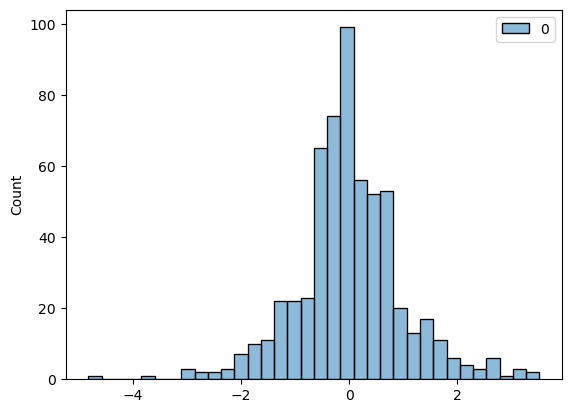

In [65]:
import seaborn as sns
sns.histplot(la_trans)

In [67]:
import numpy as np
np.log(df['LoanAmount'])
df['LoanAmount']**(2)
print(df)

      Loan_ID  ApplicantIncome  CoapplicantIncome  LoanAmount  \
0    LP001002             5849                0.0         NaN   
1    LP001003             4583             1508.0       128.0   
2    LP001005             3000                0.0        66.0   
3    LP001006             2583             2358.0       120.0   
4    LP001008             6000                0.0       141.0   
..        ...              ...                ...         ...   
609  LP002978             2900                0.0        71.0   
610  LP002979             4106                0.0        40.0   
611  LP002983             8072              240.0       253.0   
612  LP002984             7583                0.0       187.0   
613  LP002990             4583                0.0       133.0   

     Loan_Amount_Term  PA_Semiurban  PA_Urban  _Male  _Yes  _Not Graduate  _1  \
0               360.0             0         1      1     0              0   0   
1               360.0             0         0      1     